In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import signal
from scipy.stats import zscore
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.stattools import acf
import warnings
warnings.filterwarnings("ignore")

plt.rcParams['figure.figsize'] = (13, 4)
plt.rcParams['figure.dpi'] = 100


In [2]:
df = pd.read_csv("datos/dataset_horno_sostenimiento2_CORREGIDO.csv", parse_dates=["timestamp"]).set_index("timestamp")
df['sensor_temp_main'] = df['sensor_temp_main'].interpolate(method='time', limit_direction='both')
df['sensor_temp_backup'] = df['sensor_temp_backup'].interpolate(method='time', limit_direction='both')

FEATURES = ['sensor_temp_main', 'sensor_temp_backup', 'setpoint', 'heater_power_pct',
            'electrical_current', 'electrical_voltage', 'aluminum_level_pct',
            'ambient_temp', 'energy_consumption_kwh', 'lid_open_pct', 'production_draw_rate']
print(f"Muestras: {len(df)} | Features: {len(FEATURES)}")


Muestras: 20160 | Features: 11


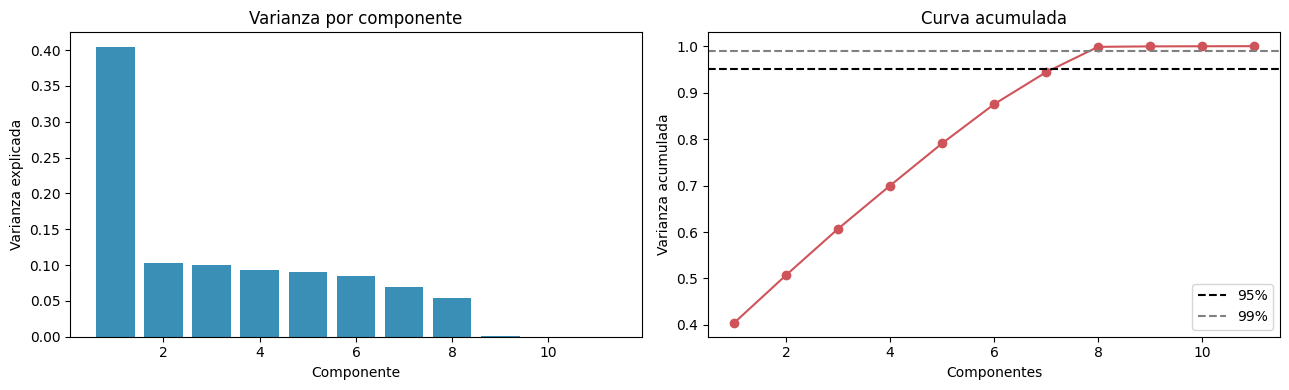

95% de varianza alcanzada con 8 componentes
99% de varianza alcanzada con 8 componentes


In [3]:
scaler = StandardScaler()
X = scaler.fit_transform(df[FEATURES].values)
pca = PCA().fit(X)
cum = np.cumsum(pca.explained_variance_ratio_)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].bar(range(1, len(FEATURES)+1), pca.explained_variance_ratio_, color='#3a8fb7')
ax[0].set_xlabel('Componente'); ax[0].set_ylabel('Varianza explicada')
ax[0].set_title('Varianza por componente')

ax[1].plot(range(1, len(FEATURES)+1), cum, 'o-', color='#cf545a')
ax[1].axhline(0.95, color='black', ls='--', label='95%')
ax[1].axhline(0.99, color='gray', ls='--', label='99%')
ax[1].set_xlabel('Componentes'); ax[1].set_ylabel('Varianza acumulada')
ax[1].set_title('Curva acumulada')
ax[1].legend()
plt.tight_layout(); plt.show()

print(f"95% de varianza alcanzada con {np.argmax(cum >= 0.95)+1} componentes")
print(f"99% de varianza alcanzada con {np.argmax(cum >= 0.99)+1} componentes")


In [4]:
def find_glitches(s, t=5):
    return (s.diff().abs() > t) & (s.diff(-1).abs() > t)

g_main = find_glitches(df['sensor_temp_main'])
g_backup = find_glitches(df['sensor_temp_backup'])
total_anom = g_main | g_backup

print(f"Glitches main: {g_main.sum()}")
print(f"Glitches backup: {g_backup.sum()}")
print(f"Total anomalías puntuales: {total_anom.sum()} ({total_anom.mean()*100:.3f}%)")


Glitches main: 60
Glitches backup: 14
Total anomalías puntuales: 74 (0.367%)


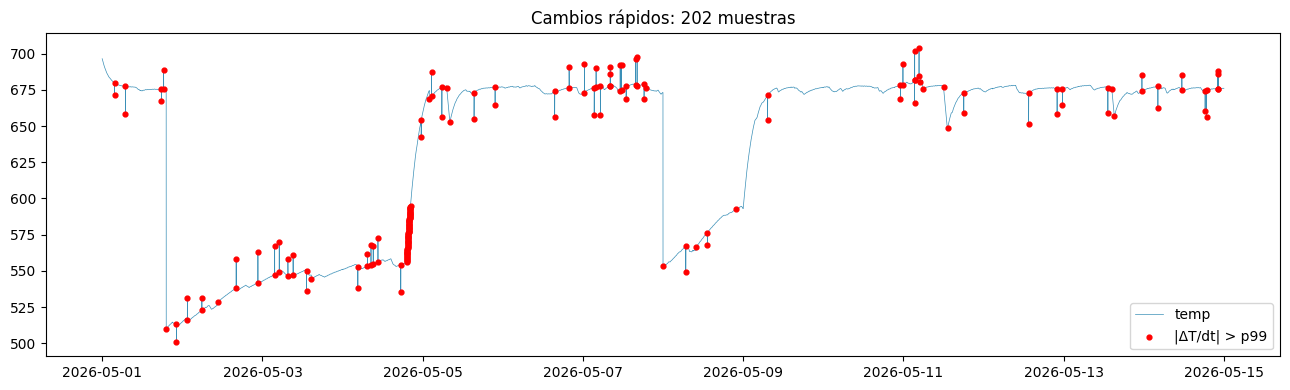

In [5]:
dT = df['sensor_temp_main'].diff()
strong = (dT.abs() > dT.abs().quantile(0.99))
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(df.index, df['sensor_temp_main'], lw=0.5, color='#3a8fb7', label='temp')
ax.scatter(df.index[strong], df['sensor_temp_main'][strong], color='red', s=12, label='|ΔT/dt| > p99', zorder=5)
ax.set_title(f'Cambios rápidos: {strong.sum()} muestras')
ax.legend(); plt.tight_layout(); plt.show()


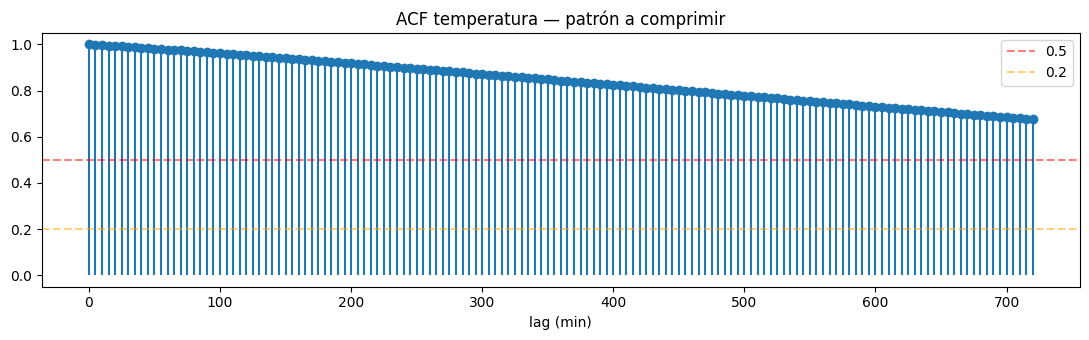

Memoria efectiva (ACF<0.5): ~>12h min


In [6]:
s5 = df['sensor_temp_main'].resample('5min').mean()
a = acf(s5, nlags=144, fft=True)
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.stem(np.arange(145)*5, a, basefmt=' ')
ax.axhline(0.5, color='red', ls='--', alpha=0.5, label='0.5')
ax.axhline(0.2, color='orange', ls='--', alpha=0.5, label='0.2')
ax.set_title('ACF temperatura — patrón a comprimir')
ax.set_xlabel('lag (min)'); ax.legend()
plt.tight_layout(); plt.show()

l50 = next((i for i, v in enumerate(a) if v < 0.5), None)
print(f"Memoria efectiva (ACF<0.5): ~{l50*5 if l50 else '>12h'} min")


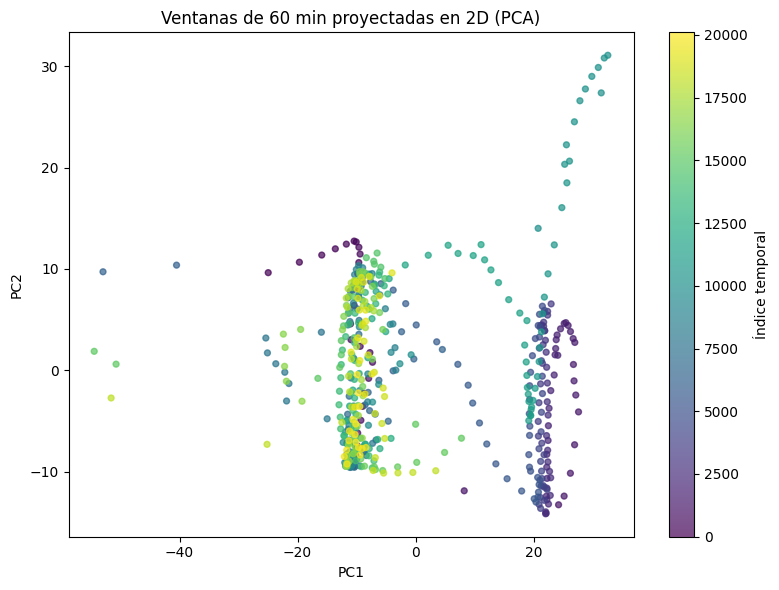

In [7]:
W = 60
n_samples = len(df) - W + 1
sample_idx = np.linspace(0, n_samples-1, 500).astype(int)
windows = np.stack([X[i:i+W].flatten() for i in sample_idx])

pca2 = PCA(n_components=2).fit_transform(windows)
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(pca2[:, 0], pca2[:, 1], c=sample_idx, cmap='viridis', s=18, alpha=0.7)
plt.colorbar(sc, label='Índice temporal')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title(f'Ventanas de {W} min proyectadas en 2D (PCA)')
plt.tight_layout(); plt.show()


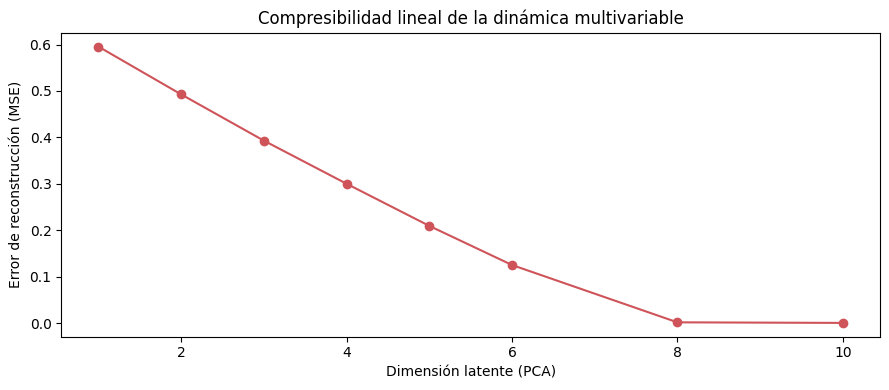

k= 1: MSE = 0.5955
k= 2: MSE = 0.4926
k= 3: MSE = 0.3930
k= 4: MSE = 0.3001
k= 5: MSE = 0.2093
k= 6: MSE = 0.1250
k= 8: MSE = 0.0014
k=10: MSE = 0.0002


In [8]:
recon_errors = []
ks = [1, 2, 3, 4, 5, 6, 8, 10]
for k in ks:
    p = PCA(n_components=k).fit(X)
    X_rec = p.inverse_transform(p.transform(X))
    err = np.mean((X - X_rec)**2)
    recon_errors.append(err)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(ks, recon_errors, 'o-', color='#cf545a')
ax.set_xlabel('Dimensión latente (PCA)'); ax.set_ylabel('Error de reconstrucción (MSE)')
ax.set_title('Compresibilidad lineal de la dinámica multivariable')
plt.tight_layout(); plt.show()

for k, e in zip(ks, recon_errors):
    print(f"k={k:2d}: MSE = {e:.4f}")


In [9]:
from scipy.stats import skew, kurtosis
stats = pd.DataFrame({
    'mean': df[FEATURES].mean(),
    'std': df[FEATURES].std(),
    'skew': df[FEATURES].apply(skew),
    'kurt': df[FEATURES].apply(kurtosis),
}).round(3)
stats


,mean,std,skew,kurt
sensor_temp_main,637.901,57.657,-0.990,-0.832
sensor_temp_backup,634.772,57.425,-0.984,-0.846
setpoint,700.000,0.707,0.000,-1.500
heater_power_pct,83.777,14.212,-1.595,8.523
electrical_current,90.264,13.732,-2.343,14.399
electrical_voltage,439.972,3.340,-0.016,-0.724
aluminum_level_pct,90.305,8.413,-4.201,20.276
ambient_temp,24.002,3.553,-0.002,-1.470
energy_consumption_kwh,1.147,0.175,-2.296,14.008
lid_open_pct,3.764,6.259,3.619,13.263


In [10]:
W = 60
H = 15
n = len(df) - W - H + 1
n_train = int(n * 0.70)
n_val = int(n * 0.15)
n_test = n - n_train - n_val
print(f"Ventanas totales (W={W}, H={H}): {n}")
print(f"Train: {n_train} | Val: {n_val} | Test: {n_test}")
print(f"Features: {len(FEATURES)} | Parámetros entrada por ventana: {W*len(FEATURES)}")


Ventanas totales (W=60, H=15): 20086
Train: 14060 | Val: 3012 | Test: 3014
Features: 11 | Parámetros entrada por ventana: 660


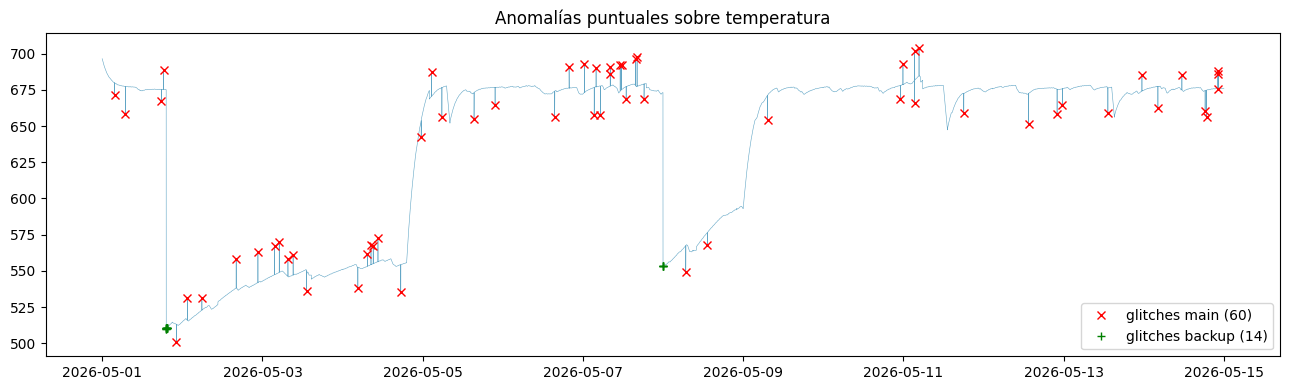

In [11]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(df.index, df['sensor_temp_main'], lw=0.4, color='#3a8fb7', alpha=0.8)
ax.plot(df.index[g_main], df['sensor_temp_main'][g_main], 'rx', label=f'glitches main ({g_main.sum()})')
ax.plot(df.index[g_backup], df['sensor_temp_main'][g_backup], 'g+', label=f'glitches backup ({g_backup.sum()})')
ax.set_title('Anomalías puntuales sobre temperatura')
ax.legend(); plt.tight_layout(); plt.show()
